# BookPulse - A Hotel Booking Demand Predicting Model

## Data Preprocessing

**Pipeline order used in this notebook**

1. Handle missing values and duplicate records
2. Remove data-leakage columns
3. Correct data types
4. Feature engineering
5. Identify categorical columns and encode them
6. Stratified train/test split
7. Feature selection (correlation, multicollinearity, mutual information, Random Forest importance) — computed on the training set only
8. Feature scaling — fit on the training set only
9. Class imbalance check (SMOTE / class weighting is applied later, at model-training time, using the training set only)

The train/test split happens **before** any feature-selection scoring or scaling, so that no information from the test set influences preprocessing decisions.

Importing required libraries for preprocessing

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

testing connection to google colab

In [7]:
import platform
import sys

print("Python:", sys.version)
print("OS:", platform.system())
print("Machine:", platform.machine())

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
OS: Linux
Machine: x86_64


connecting google drive to fetch the dataset

In [8]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Importing the dataset and fetching the first few rows of the dataset

In [9]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/BookPulse/dataset/hotel_bookings.csv"
)

print('No of Rows: ', df.shape[0])
print('No of Columns: ', df.shape[1])

df.head()

No of Rows:  119390
No of Columns:  32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### 1. Null Values and Duplicate Values

Checking for null values and duplicate values

In [10]:
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
 hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              1634

In [11]:
print(df.country.head())
print(df.agent.head())

0    PRT
1    PRT
2    GBR
3    GBR
4    GBR
Name: country, dtype: object
0      NaN
1      NaN
2      NaN
3    304.0
4    240.0
Name: agent, dtype: float64


Handling Null and Duplicate Values

1. Removed the `company` column, as it contains approximately 94% missing
   values (~112,000 records), making it unsuitable as a reliable feature
   for the model.
2. Removed the `agent` column, as it is a high-cardinality identifier
   feature not essential to predicting cancellation, and simplifies the
   feature set.
3. Removed records with missing values in `country` (~488 rows) and
   `children` (4 rows), as these represent a negligible fraction of the
   dataset (119,390 records total) and their removal does not
   meaningfully affect the data distribution.
4. Removed duplicate records, since the dataset retains a sufficiently
   large sample size for model training even after their removal.

In [12]:
# 1. Delete columns (company, agent)
df = df.drop(columns=['company', 'agent'])

# 2. Delete rows with missing values in specific columns (country, children)
df = df.dropna(subset=['country', 'children'])

# 3. Delete duplicate rows
df = df.drop_duplicates()

# Check the result
print(df.shape)
print("Null values:", df.isnull().sum().sum())
print("\nDuplicate rows:", df.duplicated().sum())

(86914, 30)
Null values: 0

Duplicate rows: 0


### 2. Outlier Treatment

`adr` (Average Daily Rate) was flagged during the initial data-quality
review as containing invalid negative values and at least one extreme
outlier (a maximum well above 5,000, versus a typical range in the low
hundreds). `lead_time` was also reviewed for extreme values.

                adr     lead_time
count  86914.000000  86914.000000
mean     106.580816     80.202741
std       54.959600     86.102902
min       -6.380000      0.000000
25%       72.250000     12.000000
50%       98.410000     50.000000
75%      134.100000    125.000000
max     5400.000000    737.000000


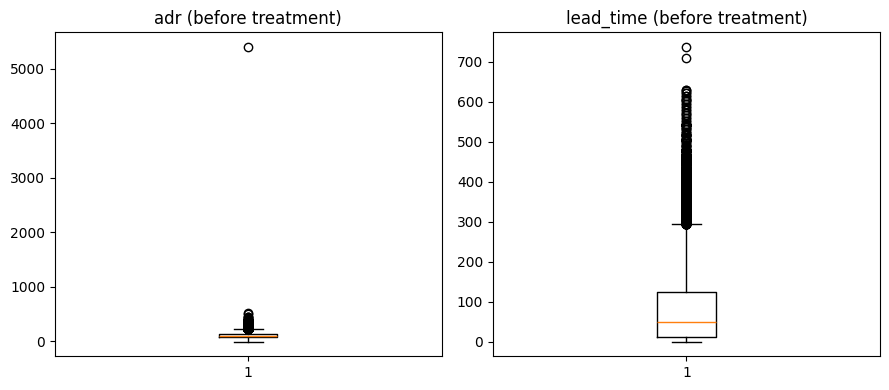

Negative adr rows: 1
adr == 0 rows: 1762
adr > 1000 rows: 1
Max adr: 5400.0


In [13]:
print(df[['adr', 'lead_time']].describe())

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].boxplot(df['adr'])
axes[0].set_title('adr (before treatment)')
axes[1].boxplot(df['lead_time'])
axes[1].set_title('lead_time (before treatment)')
plt.tight_layout()
plt.show()

print("Negative adr rows:", (df['adr'] < 0).sum())
print("adr == 0 rows:", (df['adr'] == 0).sum())
print("adr > 1000 rows:", (df['adr'] > 1000).sum())
print("Max adr:", df['adr'].max())

In [14]:
# Remove invalid negative adr values (data-entry errors)
df = df[df['adr'] >= 0]

# Cap extreme high adr values at the 99.5th percentile (winsorizing)
upper_cap = df['adr'].quantile(0.995)
print("99.5th percentile adr cap:", upper_cap)
df['adr'] = np.where(df['adr'] > upper_cap, upper_cap, df['adr'])

print(df['adr'].describe())

99.5th percentile adr cap: 285.0
count    86913.000000
mean       106.368054
std         51.317025
min          0.000000
25%         72.250000
50%         98.410000
75%        134.100000
max        285.000000
Name: adr, dtype: float64


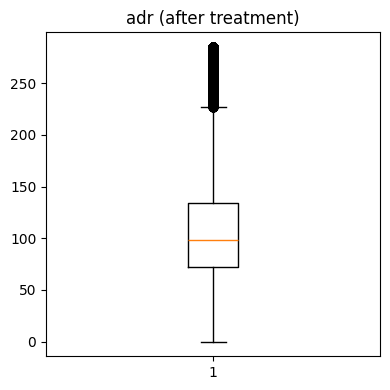

In [15]:
#after correcting adr outliners
plt.figure(figsize=(4, 4))
plt.boxplot(df['adr'])
plt.title('adr (after treatment)')
plt.tight_layout()
plt.show()

### 3. Dropping Data-Leakage Columns

`reservation_status` and `reservation_status_date` directly encode the
booking outcome (e.g. "Canceled"), so keeping them would let the model
"cheat" by reading the answer instead of learning to predict it. Both
columns are removed here, before any further preprocessing.

In [16]:
# Delete leakage columns (reservation_status, reservation_status_date)
df = df.drop(columns=['reservation_status', 'reservation_status_date'])

# check
print(df.shape)

(86913, 28)


### 4. Data Type Correction

1. Checked the data type of all columns using `df.dtypes` / `df.info()`
   to identify any columns stored in an incorrect or suboptimal format.
2. Converted the `children` column from `float64` to `int64`, as it was
   stored with decimal values (e.g., `2.0`) despite representing whole
   numbers of guests. This conversion was performed after handling
   missing values in `children`, since integer conversion fails on
   columns containing null values.
3. All remaining numeric columns were already stored in an appropriate
   numeric format and required no further correction. Categorical/text
   columns were left as `object` at this stage, to be converted during
   the encoding step later in preprocessing.

In [17]:
df.info()

# fixing children data type to int
df['children'] = df['children'].astype(int)

print('Children data type:', df['children'].dtype)

<class 'pandas.core.frame.DataFrame'>
Index: 86913 entries, 0 to 119389
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           86913 non-null  object 
 1   is_canceled                     86913 non-null  int64  
 2   lead_time                       86913 non-null  int64  
 3   arrival_date_year               86913 non-null  int64  
 4   arrival_date_month              86913 non-null  object 
 5   arrival_date_week_number        86913 non-null  int64  
 6   arrival_date_day_of_month       86913 non-null  int64  
 7   stays_in_weekend_nights         86913 non-null  int64  
 8   stays_in_week_nights            86913 non-null  int64  
 9   adults                          86913 non-null  int64  
 10  children                        86913 non-null  float64
 11  babies                          86913 non-null  int64  
 12  meal                            8691

### 4. Feature Engineering

1. Created `total_guests` (adults + children + babies) to represent the
   overall party size in a single feature, and to identify invalid
   records where total guests equal zero.
2. Created `total_nights` (stays_in_weekend_nights + stays_in_week_nights)
   to capture overall length of stay, a known factor in cancellation
   likelihood, as a single combined feature.
3. Created `previous_cancellations_ratio` (previous_cancellations divided
   by total previous bookings) to represent guest reliability as a
   proportion rather than a raw count. Guests with no prior booking
   history (denominator = 0) are assigned a ratio of 0, representing no
   known cancellation risk rather than an undefined value.

In [18]:
# total guests
df['total_guests'] = df['adults'] + df['children'] + df['babies']

# total nights
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# previous cancellation ratio (guest reliability), safe against divide-by-zero
denominator = df['previous_cancellations'] + df['previous_bookings_not_canceled']
df['previous_cancellations_ratio'] = np.where(
    denominator == 0, 0, df['previous_cancellations'] / denominator
)

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_nights,previous_cancellations_ratio
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,0,Transient,0.0,0,0,2,0,0.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,0,Transient,0.0,0,0,2,0,0.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,0,Transient,75.0,0,0,1,1,0.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,0,Transient,75.0,0,0,1,1,0.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,0,Transient,98.0,0,1,2,2,0.0


Checking the new features for zero and missing values

In [19]:
print("\nMissing values:\n", df.isnull().sum())

# checking for zero values in total_guests and total_nights columns
print("total_guests == 0:", (df['total_guests'] == 0).sum())
print("total_nights == 0:", (df['total_nights'] == 0).sum())

# checking for null values in previous_cancellations_ratio
print("previous_cancellations_ratio NaN:", df['previous_cancellations_ratio'].isna().sum())


Missing values:
 hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_s

Handling invalid records surfaced by the new features

A booking with zero total guests or zero total nights is not a valid
reservation, so these rows are removed.

In [20]:
df = df[df['total_guests'] > 0]
df = df[df['total_nights'] > 0]

print("total_guests == 0:", (df['total_guests'] == 0).sum())
print("total_nights == 0:", (df['total_nights'] == 0).sum())
print("previous_cancellations_ratio NaN:", df['previous_cancellations_ratio'].isna().sum())
print(df.shape)

total_guests == 0: 0
total_nights == 0: 0
previous_cancellations_ratio NaN: 0
(86166, 31)


### 5. Identifying Categorical Columns

Before encoding, all categorical (text/object-type) columns were
identified using `df.select_dtypes(include='object')`, and the number
of unique values in each was checked using `.nunique()`. This
determined which columns qualified as low-cardinality (suitable for
One-Hot Encoding) versus high-cardinality (requiring Frequency Encoding
instead), based on a threshold of 15 unique categories, rather than
assuming the encoding strategy for each column in advance.

In [21]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(categorical_cols)

['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


In [22]:
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

hotel: 2 unique values
arrival_date_month: 12 unique values
meal: 5 unique values
country: 177 unique values
market_segment: 7 unique values
distribution_channel: 5 unique values
reserved_room_type: 9 unique values
assigned_room_type: 11 unique values
deposit_type: 3 unique values
customer_type: 4 unique values


In [23]:
threshold = 15

low_card_cols = [col for col in categorical_cols if df[col].nunique() <= threshold]
high_card_cols = [col for col in categorical_cols if df[col].nunique() > threshold]

print("Low cardinality (one-hot):", low_card_cols)
print("High cardinality (frequency encode):", high_card_cols)

Low cardinality (one-hot): ['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
High cardinality (frequency encode): ['country']


### 6. Encoding Categorical Variables

One-Hot Encoding was applied to low-cardinality columns, converting
each into separate binary (0/1) columns (`drop_first=True` avoids
redundant columns and multicollinearity). Frequency Encoding was
applied to `country`, since it has ~177 unique values and One-Hot
Encoding would create that many additional sparse columns
(the curse of dimensionality).

In [24]:
# One-hot encode low-cardinality categorical columns
df = pd.get_dummies(df, columns=low_card_cols, drop_first=True)

In [25]:
# Frequency-encode the high-cardinality 'country' column
country_freq = df['country'].value_counts(normalize=True)
df['country_encoded'] = df['country'].map(country_freq)
df = df.drop(columns=['country'])

In [26]:
print(df.dtypes)
print(df.shape)  # check how many columns after encoding

is_canceled                        int64
lead_time                          int64
arrival_date_year                  int64
arrival_date_week_number           int64
arrival_date_day_of_month          int64
                                  ...   
deposit_type_Refundable             bool
customer_type_Group                 bool
customer_type_Transient             bool
customer_type_Transient-Party       bool
country_encoded                  float64
Length: 71, dtype: object
(86166, 71)


### 7. Train/Test Split

The dataset is split into training (80%) and testing (20%) subsets
using `stratify=y` on the `is_canceled` target, so both subsets keep
the same ~37% cancelled / 63% not-cancelled ratio as the full dataset.

This split is performed **before** feature selection and scaling, so
that every subsequent preprocessing decision (which features to drop,
how to scale) is based only on the training set — the test set is kept
completely unseen until model evaluation.

In [27]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True))
print("\nTest class balance:\n", y_test.value_counts(normalize=True))

X_train: (68932, 70)  X_test: (17234, 70)

Train class balance:
 is_canceled
0    0.722059
1    0.277941
Name: proportion, dtype: float64

Test class balance:
 is_canceled
0    0.722061
1    0.277939
Name: proportion, dtype: float64


### 8. Feature Selection (Training Set Only)

To determine which features were relevant to predicting cancellation,
the following checks were performed **on the training set only**:

1. **Variance check** — near-constant columns carry little information.
2. **Correlation with target** — linear relationship with `is_canceled`.
3. **Multicollinearity check** — pairs of features correlated above 0.85
   with each other, which are largely redundant.
4. **Mutual Information** — captures non-linear relationships that
   correlation can miss.
5. **Random Forest feature importance** — a model-driven relevance
   check that can also surface interaction effects.

A feature was only removed if it showed consistently low relevance
across these checks and lacked a clear domain-based justification for
inclusion.

Variance check

In [28]:
print(X_train.nunique())

lead_time                        471
arrival_date_year                  3
arrival_date_week_number          53
arrival_date_day_of_month         31
stays_in_weekend_nights           15
                                ... 
deposit_type_Refundable            2
customer_type_Group                2
customer_type_Transient            2
customer_type_Transient-Party      2
country_encoded                   82
Length: 70, dtype: int64


Correlation with the target (computed on the training set only)

In [29]:
pd.set_option('display.max_rows', None)

train_with_target = X_train.copy()
train_with_target['is_canceled'] = y_train

correlations = train_with_target.corr(numeric_only=True)['is_canceled'].sort_values(ascending=False)
print(correlations)

is_canceled                       1.000000
market_segment_Online TA          0.211874
lead_time                         0.180299
previous_cancellations_ratio      0.172005
deposit_type_Non Refund           0.164939
distribution_channel_TA/TO        0.150498
adr                               0.130305
customer_type_Transient           0.127935
country_encoded                   0.104677
total_guests                      0.097110
arrival_date_year                 0.085351
total_nights                      0.082218
stays_in_week_nights              0.081883
adults                            0.076293
children                          0.069492
meal_SC                           0.062573
stays_in_weekend_nights           0.056667
previous_cancellations            0.053249
arrival_date_month_August         0.038247
arrival_date_month_July           0.037115
reserved_room_type_G              0.027832
reserved_room_type_D              0.027740
reserved_room_type_H              0.022460
arrival_dat

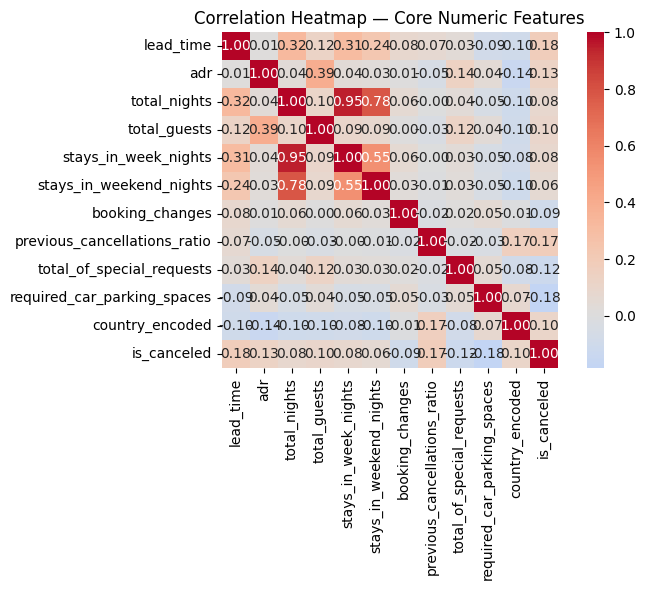

In [30]:
core_numeric = [
    'lead_time', 'adr', 'total_nights', 'total_guests',
    'stays_in_week_nights', 'stays_in_weekend_nights',
    'booking_changes', 'previous_cancellations_ratio',
    'total_of_special_requests', 'required_car_parking_spaces',
    'country_encoded', 'is_canceled'
]

plt.figure(figsize=(8, 6))
sns.heatmap(train_with_target[core_numeric].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap — Core Numeric Features')
plt.tight_layout()
plt.show()

Multicollinearity check — redundant feature pairs (training set only)

In [31]:
corr_matrix = X_train.corr(numeric_only=True)

# Keep only the upper triangle (removes duplicate mirrored pairs and self-correlation)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Extract pairs above the threshold
high_corr_pairs = upper.stack()
high_corr_pairs = high_corr_pairs[high_corr_pairs.abs() > 0.85].sort_values(ascending=False)

print(high_corr_pairs)

stays_in_week_nights     total_nights                     0.949069
market_segment_Direct    distribution_channel_Direct      0.917233
reserved_room_type_H     assigned_room_type_H             0.896891
reserved_room_type_G     assigned_room_type_G             0.882194
customer_type_Transient  customer_type_Transient-Party   -0.850626
dtype: float64


Based on the multicollinearity check, the following redundant features
are removed from both `X_train` and `X_test`:

- `stays_in_week_nights` and `stays_in_weekend_nights` (redundant with
  the engineered `total_nights` feature)
- `distribution_channel_Direct` (redundant with `market_segment_Direct`)

The negative correlation between `customer_type_Transient` and
`customer_type_Transient-Party` is a structural artifact of One-Hot
Encoding a single categorical column and requires no action.

In [32]:
redundant_cols = ['stays_in_week_nights', 'stays_in_weekend_nights', 'distribution_channel_Direct']

X_train = X_train.drop(columns=redundant_cols)
X_test = X_test.drop(columns=redundant_cols)

print(X_train.shape, X_test.shape)

(68932, 67) (17234, 67)


Mutual Information (training set only)

In [33]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_train, y_train, discrete_features='auto', random_state=42)
mi_df = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)
print(mi_df.to_string())

adr                               0.038517
lead_time                         0.037718
required_car_parking_spaces       0.033008
market_segment_Online TA          0.028170
distribution_channel_TA/TO        0.021965
country_encoded                   0.021383
previous_cancellations_ratio      0.017122
customer_type_Transient           0.015750
deposit_type_Non Refund           0.011233
total_guests                      0.010514
total_nights                      0.009909
previous_bookings_not_canceled    0.009310
adults                            0.008436
previous_cancellations            0.008234
customer_type_Transient-Party     0.008207
total_of_special_requests         0.007820
market_segment_Direct             0.007781
booking_changes                   0.007465
arrival_date_year                 0.007414
market_segment_Offline TA/TO      0.006831
arrival_date_week_number          0.006013
hotel_Resort Hotel                0.004944
is_repeated_guest                 0.004686
children   

Random Forest feature importance (training set only)

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances.to_string())

lead_time                         1.525916e-01
country_encoded                   1.044448e-01
adr                               1.033828e-01
arrival_date_day_of_month         7.866369e-02
arrival_date_week_number          6.420035e-02
total_of_special_requests         6.004391e-02
total_nights                      5.926668e-02
market_segment_Online TA          3.167734e-02
required_car_parking_spaces       2.957528e-02
arrival_date_year                 2.743138e-02
booking_changes                   1.898857e-02
total_guests                      1.571148e-02
deposit_type_Non Refund           1.521088e-02
previous_cancellations_ratio      1.491408e-02
customer_type_Transient           1.453537e-02
market_segment_Offline TA/TO      1.429390e-02
hotel_Resort Hotel                1.273122e-02
adults                            1.164963e-02
assigned_room_type_D              1.102390e-02
previous_cancellations            9.300131e-03
distribution_channel_TA/TO        8.833332e-03
reserved_room

### Final Feature Set Decision

`reserved_room_type` and `assigned_room_type` dummy columns were
largely retained, as Random Forest importance showed several room
categories (B, C, D, E, F, G) contributed meaningful predictive signal.
However, the rarest categories (H, I, K, L) were dropped, as their
importance scores were consistently far smaller than the retained
categories across all three checks.

Other features showing consistently negligible relevance across
correlation, Mutual Information, and Random Forest importance — rare
categorical dummy columns and `days_in_waiting_list` — were also
removed. These drops are applied to both `X_train` and `X_test`, using
only the relevance scores computed on the training set.

In [35]:
final_drop_cols = [
    'distribution_channel_GDS',
    'distribution_channel_Undefined',
    'market_segment_Complementary',
    'deposit_type_Refundable',
    'reserved_room_type_H', 'assigned_room_type_H',
    'reserved_room_type_L', 'assigned_room_type_L',
    'assigned_room_type_I',
    'assigned_room_type_K',
    'meal_Undefined', 'meal_FB',
    'customer_type_Group',
    'days_in_waiting_list',
]

X_train = X_train.drop(columns=final_drop_cols)
X_test = X_test.drop(columns=final_drop_cols)

print(X_train.shape, X_test.shape)

(68932, 53) (17234, 53)


### Checkpoint: Export Cleaned (Unscaled) Dataset

The cleaned, feature-selected dataset is exported here in its
**unscaled** form. Scaling is applied separately in the next step,
since tree-based models (Random Forest, Gradient Boosting) do not
require it, while distance-/gradient-based models (Logistic
Regression, KNN) do — keeping this checkpoint unscaled keeps it
reusable across every algorithm to be compared.

In [36]:
X_train.to_csv('/content/drive/MyDrive/BookPulse/dataset/X_train_clean.csv', index=False)
X_test.to_csv('/content/drive/MyDrive/BookPulse/dataset/X_test_clean.csv', index=False)
y_train.to_csv('/content/drive/MyDrive/BookPulse/dataset/y_train.csv', index=False)
y_test.to_csv('/content/drive/MyDrive/BookPulse/dataset/y_test.csv', index=False)

print("Exported cleaned, unscaled train/test files.")

Exported cleaned, unscaled train/test files.


### 9. Feature Scaling

Numeric features were scaled using `StandardScaler`, which
standardises each feature to have a mean of 0 and a standard deviation
of 1. StandardScaler was chosen over MinMaxScaler because the dataset
contains known outliers in features such as `adr`; MinMaxScaler is
highly sensitive to such outliers, while StandardScaler is
comparatively robust.

One-hot encoded categorical dummy columns and binary flags (e.g.,
`is_repeated_guest`) are excluded from scaling, as they are already on
a 0/1 scale.

Consistent with the leakage-prevention approach used throughout
preprocessing, the scaler is fit exclusively on the training set
(`fit_transform`) and then applied to the test set using the
parameters learned from training data only (`transform`, without
refitting).

In [37]:
# Columns to scale — real numeric features, not one-hot dummies or binary flags
numeric_cols = [
    'lead_time', 'adr', 'arrival_date_year', 'arrival_date_week_number',
    'arrival_date_day_of_month', 'adults', 'children', 'babies',
    'total_guests', 'total_nights', 'booking_changes',
    'previous_cancellations', 'previous_bookings_not_canceled',
    'previous_cancellations_ratio',
    'required_car_parking_spaces', 'total_of_special_requests',
    'country_encoded'
]

# Everything else (one-hot dummy columns, is_repeated_guest) stays as-is

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit ONLY on training data, then transform both
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled.head()

,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,...,assigned_room_type_B,assigned_room_type_C,assigned_room_type_D,assigned_room_type_E,assigned_room_type_F,assigned_room_type_G,deposit_type_Non Refund,customer_type_Transient,customer_type_Transient-Party,country_encoded
15569,-0.100170,-1.768890,0.231659,0.698481,-1.379054,-0.30413,-0.096449,0,-0.082208,-0.102999,...,False,False,False,False,False,False,False,True,False,1.426223
47794,-0.402635,-0.311005,-1.234829,-1.339033,0.181958,-0.30413,-0.096449,0,-0.082208,-0.102999,...,False,False,False,False,False,False,False,True,False,-0.845007
90372,-0.728367,-0.311005,-0.281612,-1.565423,0.181958,-0.30413,-0.096449,0,-0.082208,-0.102999,...,False,False,True,False,False,False,False,True,False,-0.295338
99389,-0.937766,-0.311005,1.111553,-0.433471,-1.379054,-0.30413,-0.096449,0,-0.082208,-0.102999,...,True,False,False,False,False,False,False,True,False,-0.958416
118033,2.319552,1.146880,0.378308,-0.886252,0.181958,-0.30413,-0.096449,0,-0.082208,-0.102999,...,False,False,False,False,False,False,False,True,False,-1.111824


In [39]:
X_train_scaled.to_csv('/content/drive/MyDrive/BookPulse/dataset/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('/content/drive/MyDrive/BookPulse/dataset/X_test_scaled.csv', index=False)

print("Exported scaled train/test files.")

Exported scaled train/test files.


### 10. Class Imbalance Check

The target variable is moderately imbalanced (~37% cancelled vs. 63%
not cancelled). This is checked here for reporting purposes; the
actual imbalance-handling technique (e.g., SMOTE, class weighting, or
Balanced Random Forest) is applied at model-training time, using the
training set only, so it is not part of this preprocessing notebook.

is_canceled
0    49773
1    19159
Name: count, dtype: int64

Testing set cancellation rate: 27.79%


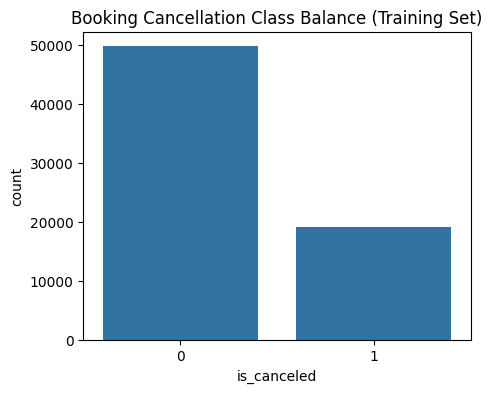

In [40]:
print(y_train.value_counts())
print("\nTesting set cancellation rate: {:.2f}%".format(y_train.mean() * 100))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=y_train, ax=ax)
ax.set_title("Booking Cancellation Class Balance (Training Set)")
ax.set_xlabel("is_canceled")
plt.show()

is_canceled
0    12444
1     4790
Name: count, dtype: int64

Training set cancellation rate: 27.79%


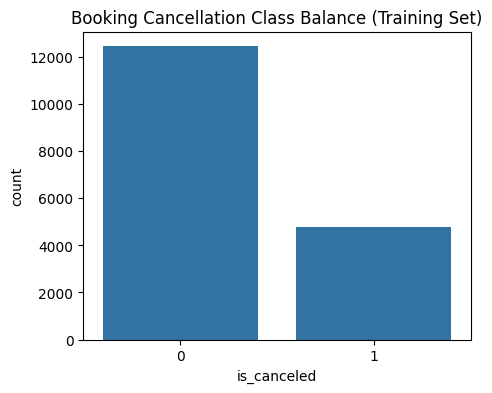

In [41]:
print(y_test.value_counts())
print("\nTraining set cancellation rate: {:.2f}%".format(y_test.mean() * 100))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=y_test, ax=ax)
ax.set_title("Booking Cancellation Class Balance (Training Set)")
ax.set_xlabel("is_canceled")
plt.show()